# Walmart - Prédiction des ventes hebdomadaires

## Part 1 : EDA & Preprocessing

Objectif : explorer les données, nettoyer le dataset et préparer les features pour la modélisation.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', None)
pd.options.display.float_format = '{:.2f}'.format

import warnings
warnings.filterwarnings('ignore')

## 1. Chargement et audit des données

In [2]:
df = pd.read_csv("../data/raw/Walmart_Store_sales.csv")
print(f"Dataset : {df.shape[0]} lignes, {df.shape[1]} colonnes")
display(df.head())
df.info()

Dataset : 150 lignes, 8 colonnes


,Store,Date,Weekly_Sales,Holiday_Flag,Temperature,Fuel_Price,CPI,Unemployment
0,6.00,18-02-2011,1572117.54,NaN,59.61,3.04,214.78,6.86
1,13.00,25-03-2011,1807545.43,0.00,42.38,3.44,128.62,7.47
2,17.00,27-07-2012,NaN,0.00,NaN,NaN,130.72,5.94
3,11.00,NaN,1244390.03,0.00,84.57,NaN,214.56,7.35
4,6.00,28-05-2010,1644470.66,0.00,78.89,2.76,212.41,7.09


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 8 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Store         150 non-null    float64
 1   Date          132 non-null    object 
 2   Weekly_Sales  136 non-null    float64
 3   Holiday_Flag  138 non-null    float64
 4   Temperature   132 non-null    float64
 5   Fuel_Price    136 non-null    float64
 6   CPI           138 non-null    float64
 7   Unemployment  135 non-null    float64
dtypes: float64(7), object(1)
memory usage: 9.5+ KB


In [3]:
df.describe()

,Store,Weekly_Sales,Holiday_Flag,Temperature,Fuel_Price,CPI,Unemployment
count,150.00,136.00,138.00,132.00,136.00,138.00,135.00
mean,9.87,1249535.83,0.08,61.40,3.32,179.90,7.60
std,6.23,647463.04,0.27,18.38,0.48,40.27,1.58
min,1.00,268929.03,0.00,18.79,2.51,126.11,5.14
25%,4.00,605075.72,0.00,45.59,2.85,131.97,6.60
50%,9.00,1261423.86,0.00,62.98,3.45,197.91,7.47
75%,15.75,1806386.20,0.00,76.34,3.71,214.93,8.15
max,20.00,2771397.17,1.00,91.65,4.19,226.97,14.31


In [4]:
df['Weekly_Sales'].dropna().describe()

count       136.00
mean    1249535.83
std      647463.04
min      268929.03
25%      605075.72
50%     1261423.86
75%     1806386.20
max     2771397.17
Name: Weekly_Sales, dtype: float64

### 1.1 Nettoyage de la target (`Weekly_Sales`)

On ne fait jamais d'imputation sur la target → on drop les lignes manquantes.

In [5]:
missing_target = df['Weekly_Sales'].isnull().sum()
print(f"Target manquante : {missing_target} lignes")

df = df.dropna(subset=['Weekly_Sales'])
print(f"Après suppression : {df.shape}")

Target manquante : 14 lignes
Après suppression : (136, 8)


### 1.2 Feature engineering : dates

Extraction de Year, Month, Day, DayOfWeek depuis la colonne `Date`, puis suppression de la colonne originale.

In [6]:
df['Date'] = pd.to_datetime(df['Date'], format="%d-%m-%Y")

df['Year'] = df['Date'].dt.year
df['Month'] = df['Date'].dt.month
df['Day'] = df['Date'].dt.day
df['DayOfWeek'] = df['Date'].dt.dayofweek

df = df.drop("Date", axis=1)
display(df.head())

,Store,Weekly_Sales,Holiday_Flag,Temperature,Fuel_Price,CPI,Unemployment,Year,Month,Day,DayOfWeek
0,6.00,1572117.54,NaN,59.61,3.04,214.78,6.86,2011.00,2.00,18.00,4.00
1,13.00,1807545.43,0.00,42.38,3.44,128.62,7.47,2011.00,3.00,25.00,4.00
3,11.00,1244390.03,0.00,84.57,NaN,214.56,7.35,NaN,NaN,NaN,NaN
4,6.00,1644470.66,0.00,78.89,2.76,212.41,7.09,2010.00,5.00,28.00,4.00
5,4.00,1857533.70,0.00,NaN,2.76,126.16,7.90,2010.00,5.00,28.00,4.00


### 1.3 Suppression des outliers (règle 3 sigmas)

On exclut les valeurs hors $[\bar{X} - 3\sigma, \bar{X} + 3\sigma]$ pour Temperature, Fuel_Price, CPI et Unemployment.

In [7]:
numeric_features = ['Temperature', 'Fuel_Price', 'CPI', 'Unemployment']

print(f"Avant outliers : {df.shape}")

for col in numeric_features:
    mean = df[col].mean()
    std = df[col].std()
    lower_bound = mean - 3 * std
    upper_bound = mean + 3 * std

    mask_outliers = (df[col] >= lower_bound) & (df[col] <= upper_bound)
    df = df.loc[mask_outliers | df[col].isnull(), :]

    print(f"  {col} : [{lower_bound:.2f}, {upper_bound:.2f}]")

print(f"Après outliers : {df.shape}")

Avant outliers : (136, 11)
  Temperature : [5.31, 116.40]
  Fuel_Price : [1.88, 4.76]
  CPI : [57.36, 298.82]
  Unemployment : [2.81, 12.52]
Après outliers : (131, 11)


### 1.4 Distribution de la variable cible

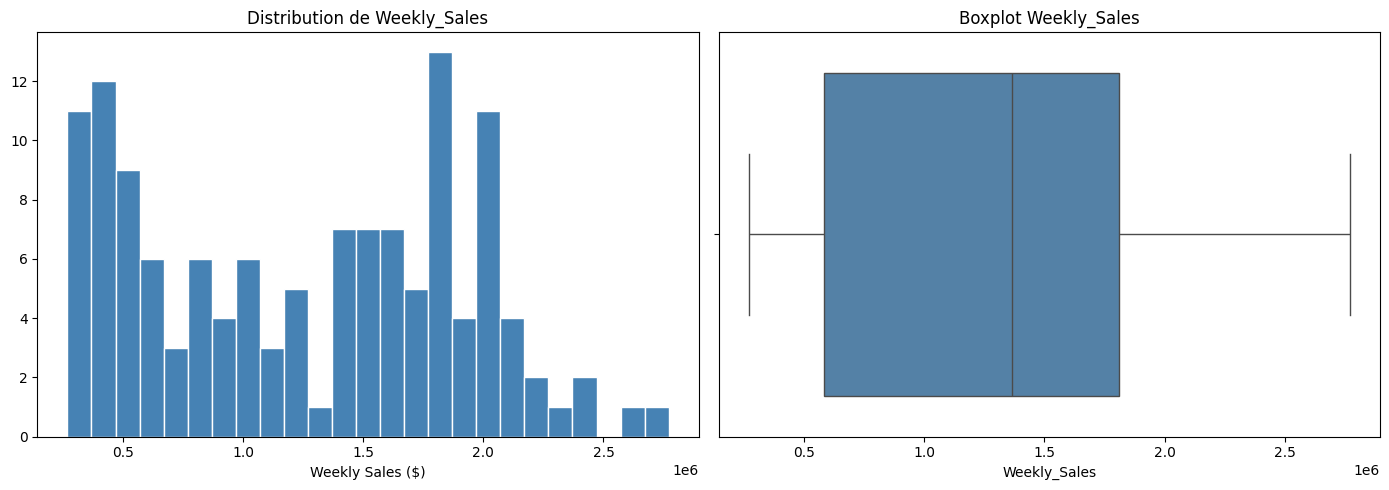

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(df['Weekly_Sales'], bins=25, color='steelblue', edgecolor='white')
axes[0].set_title("Distribution de Weekly_Sales")
axes[0].set_xlabel("Weekly Sales ($)")

sns.boxplot(x=df['Weekly_Sales'], ax=axes[1], color='steelblue')
axes[1].set_title("Boxplot Weekly_Sales")

plt.tight_layout()
plt.savefig("../assets/images/distribution_target.png", dpi=150, bbox_inches='tight')
plt.show()

## 2. Visualisation (EDA)

### 2.1 Matrice de corrélation

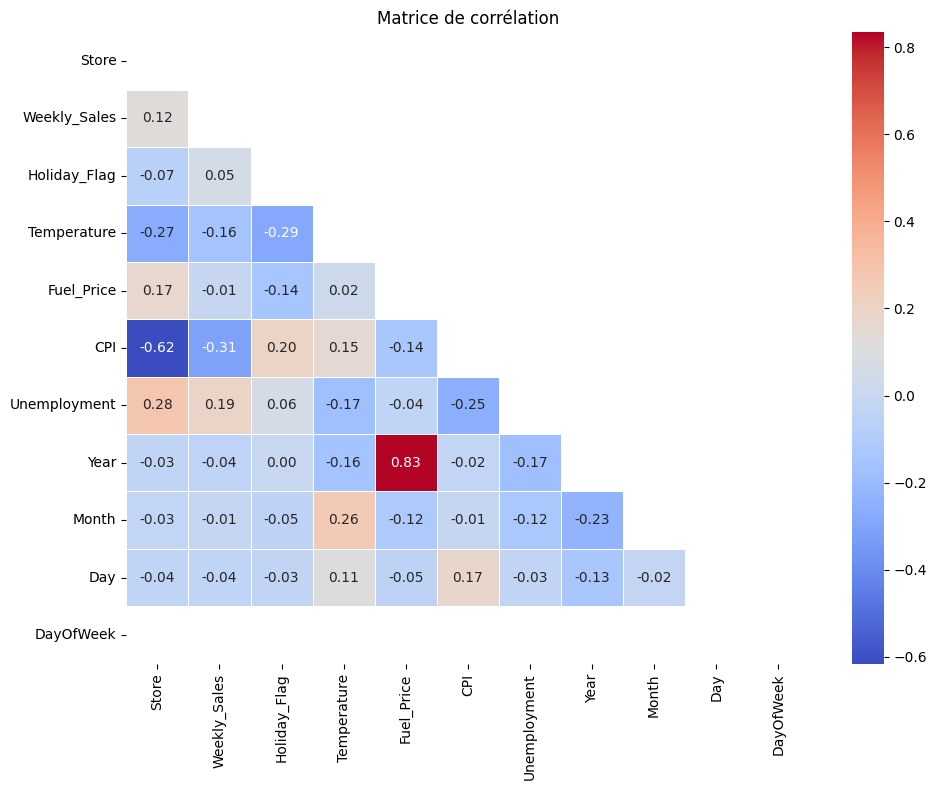

In [9]:
corr = df.corr()
mask = np.triu(np.ones_like(corr, dtype=bool))

plt.figure(figsize=(10, 8))
sns.heatmap(corr, mask=mask, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title("Matrice de corrélation")
plt.tight_layout()
plt.savefig("../assets/images/correlation_matrix.png", dpi=150, bbox_inches='tight')
plt.show()

### 2.2 Saisonnalité des ventes par mois

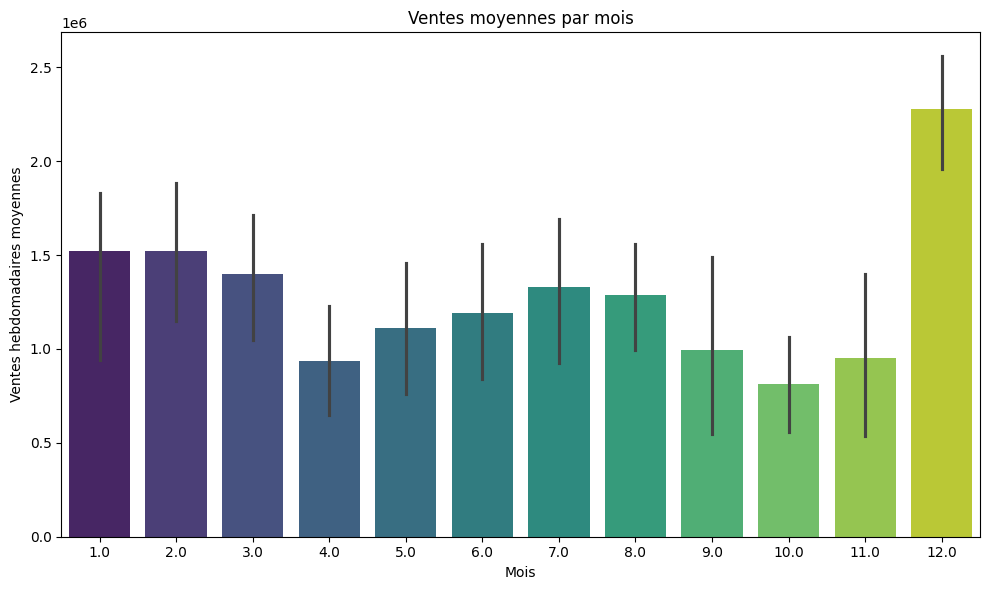

In [10]:
plt.figure(figsize=(10, 6))
sns.barplot(x='Month', y='Weekly_Sales', data=df, palette="viridis")
plt.title("Ventes moyennes par mois")
plt.xlabel("Mois")
plt.ylabel("Ventes hebdomadaires moyennes")
plt.tight_layout()
plt.savefig("../assets/images/seasonality.png", dpi=150, bbox_inches='tight')
plt.show()

### 2.3 Indicateurs économiques vs ventes

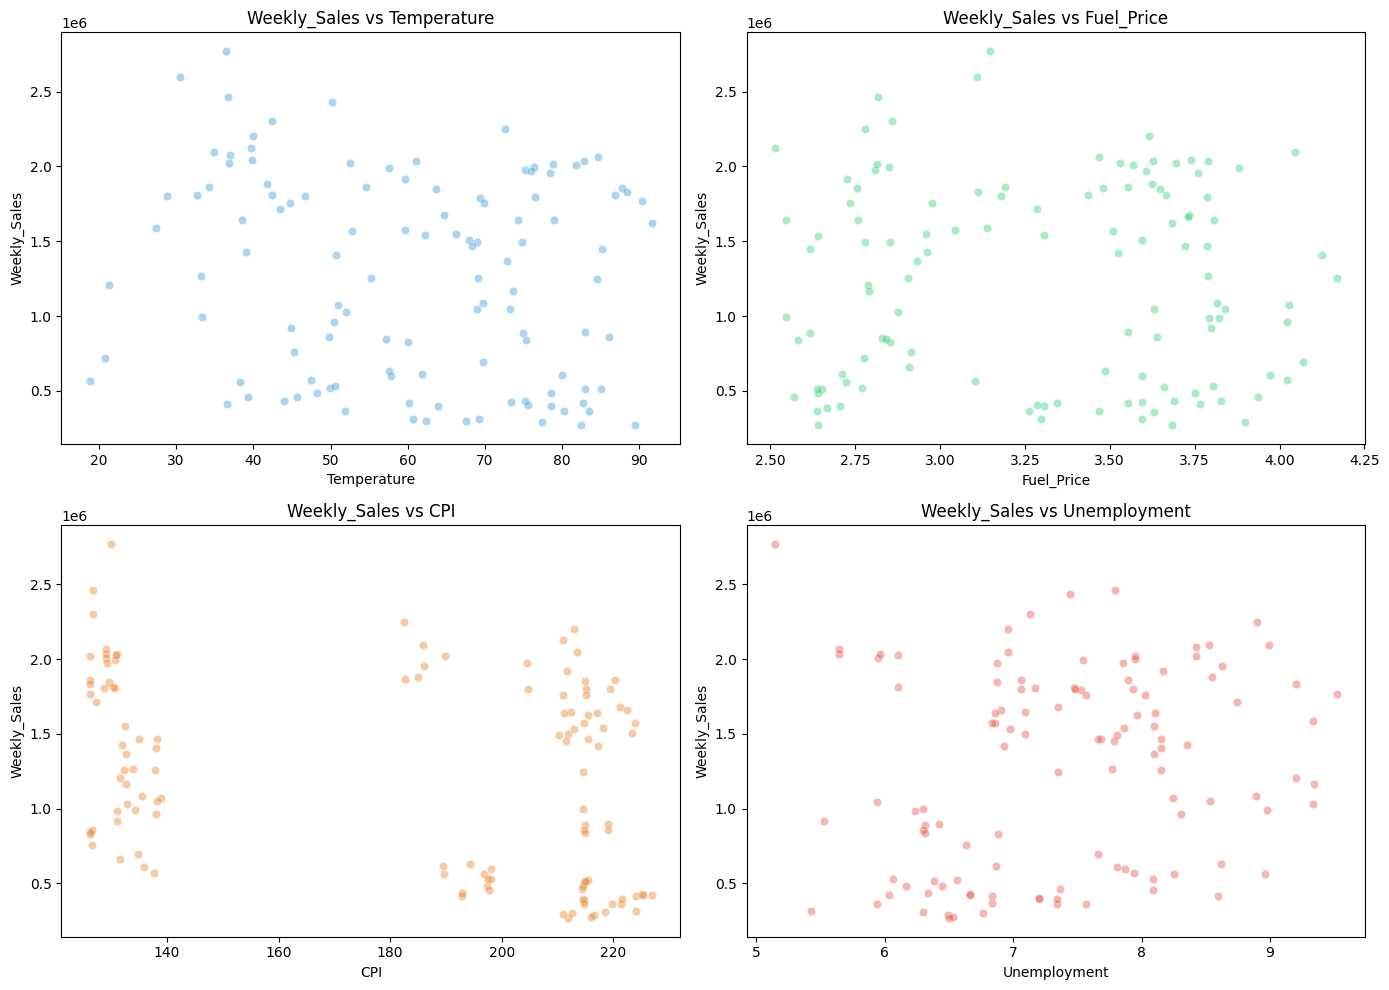

In [11]:
fig, axs = plt.subplots(2, 2, figsize=(14, 10))

features_to_plot = ['Temperature', 'Fuel_Price', 'CPI', 'Unemployment']
colors = ['#3498db', '#2ecc71', '#e67e22', '#e74c3c']

for i, feature in enumerate(features_to_plot):
    row, col = i // 2, i % 2
    sns.scatterplot(x=df[feature], y=df['Weekly_Sales'], ax=axs[row, col], color=colors[i], alpha=0.4)
    axs[row, col].set_title(f"Weekly_Sales vs {feature}")

plt.tight_layout()
plt.savefig("../assets/images/economic_indicators.png", dpi=150, bbox_inches='tight')
plt.show()

## 3. Preprocessing Scikit-Learn

### 3.1 Séparation X/Y et train/test split (80/20)

In [12]:
from sklearn.model_selection import train_test_split

Y = df['Weekly_Sales']
X = df.drop('Weekly_Sales', axis=1)

X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state=42)

print(f"X_train : {X_train.shape}, X_test : {X_test.shape}")

X_train : (104, 10), X_test : (27, 10)


### 3.2 Pipeline de preprocessing (ColumnTransformer)

- **Numériques** (Temperature, Fuel_Price, CPI, Unemployment, Year, Month, Day, DayOfWeek) : imputation moyenne + StandardScaler
- **Catégorielles** (Store, Holiday_Flag) : imputation mode + OneHotEncoder (drop='first' pour éviter la colinéarité)

In [13]:
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer

numeric_features = ['Temperature', 'Fuel_Price', 'CPI', 'Unemployment', 'Year', 'Month', 'Day', 'DayOfWeek']
categorical_features = ['Store', 'Holiday_Flag']

numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='mean')),
    ('scaler', StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(drop='first'))
])

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features),
        ('cat', categorical_transformer, categorical_features)
    ])

### 3.3 Application du preprocessing

Le `fit` se fait uniquement sur le train pour éviter le data leakage.

In [14]:
# fit sur train uniquement
X_train = preprocessor.fit_transform(X_train)
X_test = preprocessor.transform(X_test)

print(f"X_train après preprocessing : {X_train.shape}")

X_train après preprocessing : (104, 27)


## 4. Modèle Baseline : Régression Linéaire

In [15]:
from sklearn.linear_model import LinearRegression

regressor = LinearRegression()
regressor.fit(X_train, Y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


### 4.1 Évaluation des performances

In [16]:
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

Y_train_pred = regressor.predict(X_train)
Y_test_pred = regressor.predict(X_test)

print("=== Régression Linéaire ===")
print(f"R2  Train : {r2_score(Y_train, Y_train_pred):.3f} | Test : {r2_score(Y_test, Y_test_pred):.3f}")
print(f"MAE Test  : {mean_absolute_error(Y_test, Y_test_pred):,.0f} $")
print(f"RMSE Test : {np.sqrt(mean_squared_error(Y_test, Y_test_pred)):,.0f} $")

=== Régression Linéaire ===
R2  Train : 0.977 | Test : 0.891
MAE Test  : 153,208 $
RMSE Test : 194,682 $


### 4.2 Réel vs Prédit (test set)

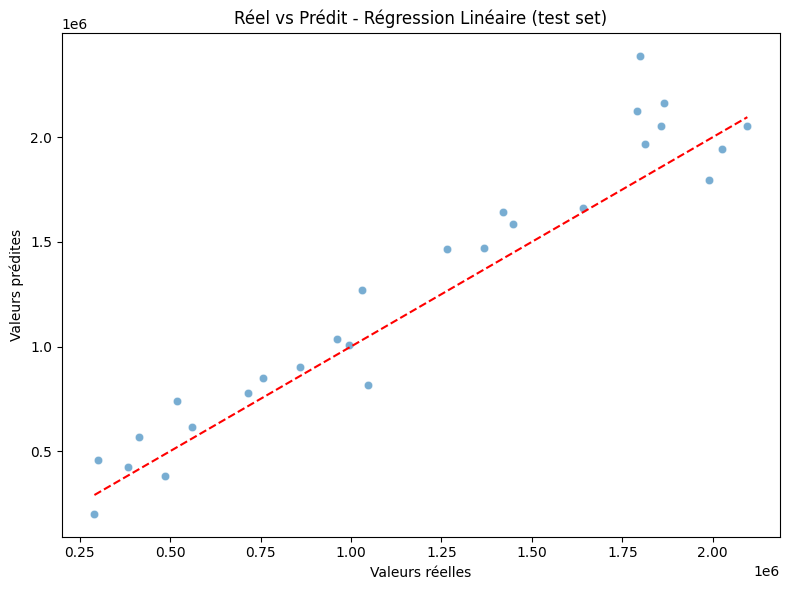

In [17]:
plt.figure(figsize=(8, 6))
sns.scatterplot(x=Y_test, y=Y_test_pred, alpha=0.6)
plt.plot([Y_test.min(), Y_test.max()], [Y_test.min(), Y_test.max()], 'r--')
plt.xlabel("Valeurs réelles")
plt.ylabel("Valeurs prédites")
plt.title("Réel vs Prédit - Régression Linéaire (test set)")
plt.tight_layout()
plt.savefig("../assets/images/real_vs_predicted.png", dpi=150, bbox_inches='tight')
plt.show()

### 4.3 Interprétation des coefficients

Top 10 features :


,Coefficient,Abs
cat__Store_5.0,-1360103.84,1360103.84
cat__Store_3.0,-1202338.02,1202338.02
cat__Store_16.0,-1176967.77,1176967.77
cat__Store_9.0,-1142851.54,1142851.54
cat__Store_7.0,-994265.38,994265.38
cat__Store_15.0,-864907.67,864907.67
cat__Store_17.0,-858056.73,858056.73
cat__Store_8.0,-797002.80,797002.80
cat__Store_14.0,579821.24,579821.24
cat__Store_4.0,487598.01,487598.01


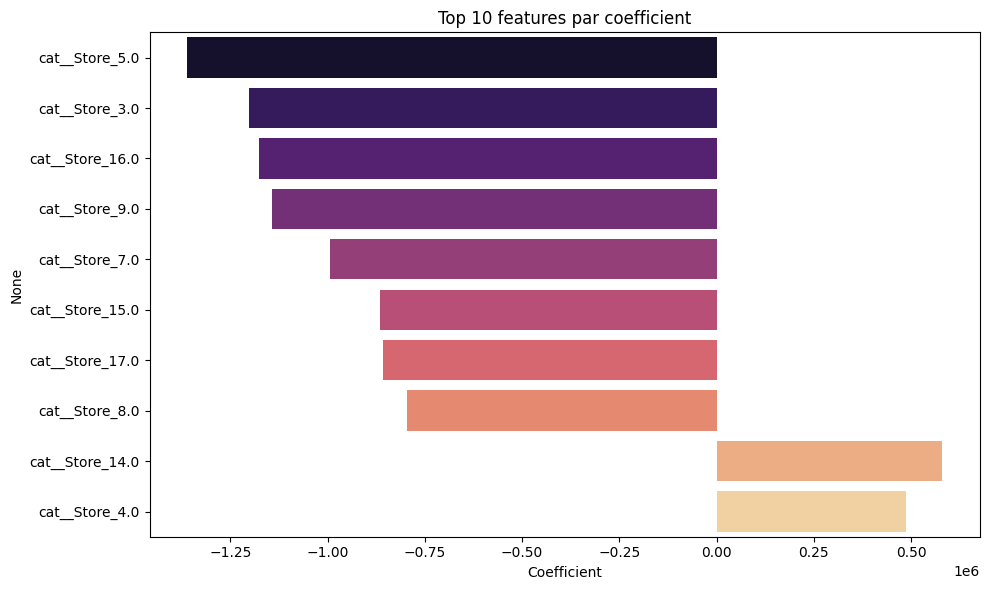

In [18]:
feature_names_out = preprocessor.get_feature_names_out()

coefs = pd.DataFrame(
    index=feature_names_out,
    data=regressor.coef_,
    columns=["Coefficient"]
)
coefs["Abs"] = coefs["Coefficient"].abs()
coefs_sorted = coefs.sort_values("Abs", ascending=False)

print("Top 10 features :")
display(coefs_sorted.head(10))

plt.figure(figsize=(10, 6))
sns.barplot(y=coefs_sorted.head(10).index, x="Coefficient", data=coefs_sorted.head(10), palette="magma")
plt.title("Top 10 features par coefficient")
plt.tight_layout()
plt.savefig("../assets/images/feature_importance.png", dpi=150, bbox_inches='tight')
plt.show()

## 5. Régularisation

### 5.1 Ridge Regression

On ajoute une pénalité L2 ($\alpha \sum \beta_i^2$) pour réduire l'overfitting observé (écart train/test).

In [19]:
from sklearn.linear_model import Ridge

# Test avec alpha=100 (volontairement élevé pour voir l'effet)
ridge_100 = Ridge(alpha=100)
ridge_100.fit(X_train, Y_train)

Y_test_pred_ridge100 = ridge_100.predict(X_test)

print("=== Ridge (alpha=100) ===")
print(f"R2  Train : {ridge_100.score(X_train, Y_train):.3f} | Test : {ridge_100.score(X_test, Y_test):.3f}")
print(f"MAE Test  : {mean_absolute_error(Y_test, Y_test_pred_ridge100):,.0f} $")
print(f"RMSE Test : {np.sqrt(mean_squared_error(Y_test, Y_test_pred_ridge100)):,.0f} $")
print("→ Alpha trop élevé : le modèle est trop pénalisé, d'où l'effondrement du R2.")

=== Ridge (alpha=100) ===
R2  Train : 0.200 | Test : 0.072
MAE Test  : 510,900 $
RMSE Test : 567,832 $
→ Alpha trop élevé : le modèle est trop pénalisé, d'où l'effondrement du R2.


### 5.2 Optimisation de alpha par GridSearchCV (Ridge)

In [20]:
from sklearn.model_selection import GridSearchCV

params = {'alpha': [0.01, 0.1, 1, 10, 50, 100, 500, 1000]}

grid_ridge = GridSearchCV(Ridge(), param_grid=params, cv=5, scoring='r2')
grid_ridge.fit(X_train, Y_train)

best_ridge = grid_ridge.best_estimator_
Y_test_pred_best_ridge = best_ridge.predict(X_test)

print(f"=== Ridge optimisé (alpha={grid_ridge.best_params_['alpha']}) ===")
print(f"R2 CV moyen : {grid_ridge.best_score_:.3f}")
print(f"R2  Train : {best_ridge.score(X_train, Y_train):.3f} | Test : {best_ridge.score(X_test, Y_test):.3f}")
print(f"MAE Test  : {mean_absolute_error(Y_test, Y_test_pred_best_ridge):,.0f} $")
print(f"RMSE Test : {np.sqrt(mean_squared_error(Y_test, Y_test_pred_best_ridge)):,.0f} $")

=== Ridge optimisé (alpha=0.01) ===
R2 CV moyen : 0.946
R2  Train : 0.977 | Test : 0.892
MAE Test  : 151,995 $
RMSE Test : 193,651 $


### 5.3 Lasso Regression (pénalité L1)

Contrairement à Ridge (L2), Lasso peut mettre des coefficients exactement à 0 → sélection de features automatique.

In [21]:
from sklearn.linear_model import Lasso

params_lasso = {'alpha': [0.01, 0.1, 1, 10, 50, 100, 500, 1000]}

grid_lasso = GridSearchCV(Lasso(max_iter=10000), param_grid=params_lasso, cv=5, scoring='r2')
grid_lasso.fit(X_train, Y_train)

best_lasso = grid_lasso.best_estimator_
Y_test_pred_lasso = best_lasso.predict(X_test)

print(f"=== Lasso optimisé (alpha={grid_lasso.best_params_['alpha']}) ===")
print(f"R2 CV moyen : {grid_lasso.best_score_:.3f}")
print(f"R2  Train : {best_lasso.score(X_train, Y_train):.3f} | Test : {best_lasso.score(X_test, Y_test):.3f}")
print(f"MAE Test  : {mean_absolute_error(Y_test, Y_test_pred_lasso):,.0f} $")
print(f"RMSE Test : {np.sqrt(mean_squared_error(Y_test, Y_test_pred_lasso)):,.0f} $")

# Coefficients à 0 (features éliminées par Lasso)
n_zeros = (best_lasso.coef_ == 0).sum()
print(f"\nFeatures éliminées par Lasso : {n_zeros}/{len(best_lasso.coef_)}")

=== Lasso optimisé (alpha=500) ===


R2 CV moyen : 0.948
R2  Train : 0.977 | Test : 0.897
MAE Test  : 151,358 $
RMSE Test : 188,738 $

Features éliminées par Lasso : 1/27


## 6. Comparaison des modèles

In [22]:
results = pd.DataFrame({
    'Modèle': ['Régression Linéaire', f'Ridge (alpha={grid_ridge.best_params_["alpha"]})', f'Lasso (alpha={grid_lasso.best_params_["alpha"]})'],
    'R2 Train': [
        r2_score(Y_train, regressor.predict(X_train)),
        best_ridge.score(X_train, Y_train),
        best_lasso.score(X_train, Y_train)
    ],
    'R2 Test': [
        r2_score(Y_test, Y_test_pred),
        best_ridge.score(X_test, Y_test),
        best_lasso.score(X_test, Y_test)
    ],
    'MAE Test': [
        mean_absolute_error(Y_test, Y_test_pred),
        mean_absolute_error(Y_test, Y_test_pred_best_ridge),
        mean_absolute_error(Y_test, Y_test_pred_lasso)
    ],
    'RMSE Test': [
        np.sqrt(mean_squared_error(Y_test, Y_test_pred)),
        np.sqrt(mean_squared_error(Y_test, Y_test_pred_best_ridge)),
        np.sqrt(mean_squared_error(Y_test, Y_test_pred_lasso))
    ]
})

results['R2 Train'] = results['R2 Train'].map('{:.3f}'.format)
results['R2 Test'] = results['R2 Test'].map('{:.3f}'.format)
results['MAE Test'] = results['MAE Test'].map('${:,.0f}'.format)
results['RMSE Test'] = results['RMSE Test'].map('${:,.0f}'.format)

display(results)

,Modèle,R2 Train,R2 Test,MAE Test,RMSE Test
0,Régression Linéaire,0.977,0.891,"$153,208","$194,682"
1,Ridge (alpha=0.01),0.977,0.892,"$151,995","$193,651"
2,Lasso (alpha=500),0.977,0.897,"$151,358","$188,738"


## 7. Conclusion

**Meilleur modèle** : Lasso (alpha=500) -- R2 test = 0.897, MAE = 151 358 $, RMSE = 188 738 $.

**Observations** :
- L'écart train/test modéré (0.977 vs 0.891 en linéaire) indique un léger overfitting, corrigé partiellement par la régularisation
- Ridge (best alpha=0.01) apporte un gain marginal (R2 test 0.892)
- Lasso (best alpha=500) donne le meilleur R2 test (0.897) et élimine 1 feature sur 27
- Le Store est de loin la feature la plus prédictive (effet taille/localisation du magasin)

**Limites** :
- Dataset très petit (131 lignes après nettoyage) : résultats sensibles au split
- OneHotEncoding de Store crée beaucoup de colonnes pour peu d'observations
- Les indicateurs économiques (CPI, Unemployment) montrent peu de corrélation linéaire avec les ventes